# Primer intento:

Algoritmo basado en los bloques fundamentales de los numeros del 1 al 20

In [23]:
def primer_intento():
    i = 32 # Desbloqueado el uso de prod(), lcm() y gcd() de math
    encontrado = False
    while True:
        for j in (9,5,7,11,13,16,17,19): 
            if i % j != 0:
                break
            else:
                encontrado = j == 19
        if encontrado:
            break
        else:
            i += 16 # el resultado deberia ser multiplo de 16
    return i

primer_intento()

232792560

# Optimizacion:

por definición de los bloques fundamentales, el mcm (lcm por sus siglas en inglés) es el producto de estos

In [25]:
from math import prod

def optimizacion():
      return prod([9,5,7,11,13,16,17,19])

optimizacion()

232792560

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 232792560
Consistente: True
Tiempo promedio: 1.227771 s
Tiempo minimo: 1.188063 s
Memoria promedio: 0.42 KB
Memoria maxima: 2.41 KB

--- Optimizacion ---
Resultado: 232792560
Consistente: True
Tiempo promedio: 0.000003 s
Tiempo minimo: 0.000002 s
Memoria promedio: 0.02 KB
Memoria maxima: 0.02 KB


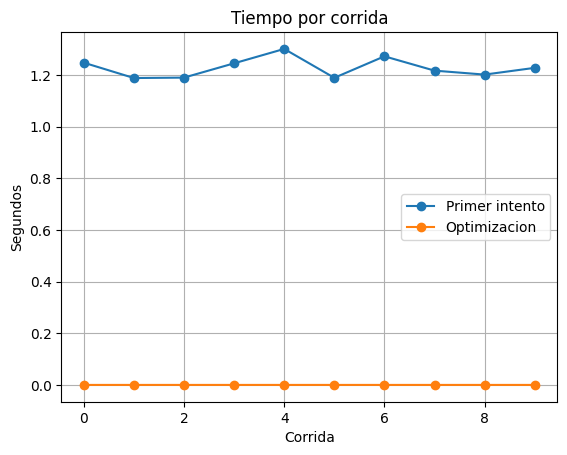

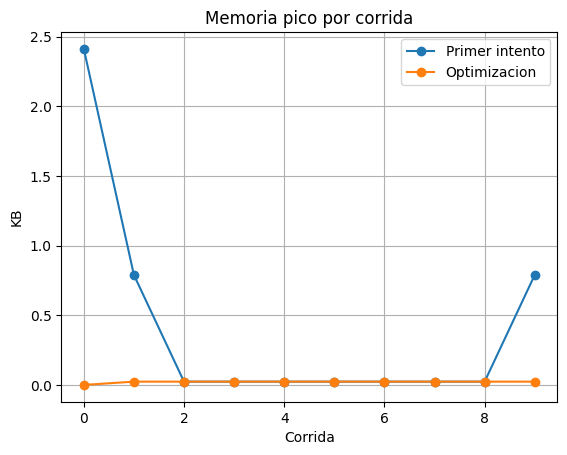

In [6]:
import time
import tracemalloc
import matplotlib.pyplot as plt


def medir(funcion, corridas=10):
    tiempos = []
    memorias = []
    resultados = []

    for _ in range(corridas):
        tracemalloc.start()

        tiempo_inicial = time.process_time()
        resultado = funcion()
        tiempo_final = time.process_time()

        _, memoria_pico = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        tiempos.append(tiempo_final - tiempo_inicial)
        memorias.append(memoria_pico / 1024)
        resultados.append(resultado)

    return {
        "resultado": resultados[0] if len(set(resultados)) == 1 else None,
        "consistente": len(set(resultados)) == 1,
        "tiempos": tiempos,
        "memorias": memorias,
    }


metodos = {
    "Primer intento": primer_intento,
    "Optimizacion": optimizacion,
}

comparaciones = {
    nombre: medir(funcion, corridas=10)
    for nombre, funcion in metodos.items()
}

for nombre, datos in comparaciones.items():
    print(f"\n--- {nombre} ---")
    print("Resultado:", datos["resultado"])
    print("Consistente:", datos["consistente"])
    print(f"Tiempo promedio: {sum(datos['tiempos']) / len(datos['tiempos']):.6f} s")
    print(f"Tiempo minimo: {min(datos['tiempos']):.6f} s")
    print(f"Memoria promedio: {sum(datos['memorias']) / len(datos['memorias']):.2f} KB")
    print(f"Memoria maxima: {max(datos['memorias']):.2f} KB")


plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["tiempos"], marker="o", label=nombre)
plt.title("Tiempo por corrida")
plt.xlabel("Corrida")
plt.ylabel("Segundos")
plt.legend()
plt.grid()

plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["memorias"], marker="o", label=nombre)
plt.title("Memoria pico por corrida")
plt.xlabel("Corrida")
plt.ylabel("KB")
plt.legend()
plt.grid()

plt.show()